In [5]:
!pip install scikit-learn

In [6]:
!pip install tensorflow opencv-python

In [42]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, BatchNormalization
from tensorflow.keras import regularizers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, f1_score, recall_score, precision_score, roc_curve, auc
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import pandas as pd
import cv2
from sklearn.utils import shuffle
import re
import tensorflow as tf
from tensorflow.keras.regularizers import l2


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


In [10]:
videos = []
classes = []

path ="/content/drive/My Drive/VideosProyecto"
normal= os.path.join(path, "normal")
suspicious = os.path.join(path, "abnormal")

videos = []
labelsDict = {0: "Normal", 1: "Abnormal"}
labels = []

for video in os.listdir(normal):
    videos.append(os.path.join(normal, video))
    labels.append(0)

for video in os.listdir(suspicious):
    videos.append(os.path.join(suspicious, video))
    labels.append(1)

df = pd.DataFrame({"videos": videos, "classes": labels})
df['videos'] = videos
df['classes'] = labels

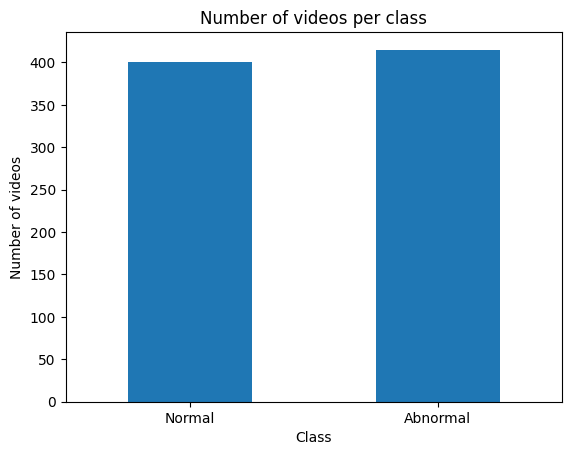

In [11]:
counts = df["classes"].value_counts().sort_index()

counts.plot(kind="bar")
plt.xticks(ticks=[0, 1], labels=["Normal", "Abnormal"], rotation=0)
plt.title("Number of videos per class")
plt.xlabel("Class")
plt.ylabel("Number of videos")
plt.show()

In [12]:
IMG_SIZE = 112
SEQUENCE_LENGTH = 25


def load_video(video_path, max_frames=SEQUENCE_LENGTH):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frames.append(frame)
    cap.release()

    while len(frames) < max_frames:
        frames.append(frames[-1])

    return np.array(frames, dtype=np.float32) / 255.0

In [13]:
df["videos"] = df["videos"].apply(load_video)

X_train, X_test, y_train, y_test = train_test_split(
    df["videos"], df["classes"], test_size=0.2, random_state=42, stratify=df["classes"]
)

In [14]:
unique, counts = np.unique(y_train, return_counts=True)
print(f"Videos de entrenamiento por clase: {dict(zip(unique, counts))}")

unique, counts = np.unique(y_test, return_counts=True)
print(f"Videos de validación por clase: {dict(zip(unique, counts))}")

Videos de entrenamiento por clase: {np.int64(0): np.int64(320), np.int64(1): np.int64(332)}
Videos de validación por clase: {np.int64(0): np.int64(80), np.int64(1): np.int64(83)}


In [15]:
X_train = np.array(X_train.tolist())
X_test = np.array(X_test.tolist())

In [56]:
def create_3d_cnn(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv3D(32, kernel_size=(1,3,3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        BatchNormalization(),

        tf.keras.layers.Conv3D(64, kernel_size=(3, 1, 1), activation='relu'),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        BatchNormalization(),

        tf.keras.layers.Conv3D(128, kernel_size=(1, 3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        BatchNormalization(),


        tf.keras.layers.Conv3D(256, kernel_size=(1, 3, 3),activation='relu'),
        tf.keras.layers.MaxPooling3D(pool_size=(2, 2, 2)),
        BatchNormalization(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

input_shape = (SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)
earlyStopping = EarlyStopping(monitor='val_accuracy', patience=6, verbose=0, restore_best_weights=True)

with tf.device('/device:GPU:0'):
  model = create_3d_cnn(input_shape)
model.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d_60 (Conv3D)              │ (None, 25, 110, 110,   │           896 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_60 (MaxPooling3D) │ (None, 12, 55, 55, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 12, 55, 55, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_61 (Conv3D)              │ (None, 10, 55, 55, 64) │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_61 (MaxPooling3D) │ (None, 5, 27, 27, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 5, 27, 27, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_62 (Conv3D)              │ (None, 5, 25, 25, 128) │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_62 (MaxPooling3D) │ (None, 2, 12, 12, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 2, 12, 12, 128) │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_63 (Conv3D)              │ (None, 2, 10, 10, 256) │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_63 (MaxPooling3D) │ (None, 1, 5, 5, 256)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 1, 5, 5, 256)   │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 789,858 (3.01 MB)

 Trainable params: 788,898 (3.01 MB)

 Non-trainable params: 960 (3.75 KB)

In [57]:
with tf.device('/device:GPU:0'):
  history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_data=(X_test, y_test), callbacks=[earlyStopping])

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - accuracy: 0.5291 - loss: 2.0459 - val_accuracy: 0.5092 - val_loss: 1.1375
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.5929 - loss: 1.6473 - val_accuracy: 0.4908 - val_loss: 2.3663
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.6099 - loss: 1.2798 - val_accuracy: 0.6012 - val_loss: 0.9722
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6700 - loss: 1.0496 - val_accuracy: 0.6319 - val_loss: 0.9488
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7122 - loss: 1.0457 - val_accuracy: 0.7669 - val_loss: 0.8574
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6914 - loss: 0.9477 - val_accuracy: 0.7239 - val_loss: 0.9283
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7265 - loss: 0.8927 - val_accuracy: 0.8282 - val_loss: 0.7811
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.7115 - loss: 0.9108 - val_accuracy: 0.7975 -

In [58]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9030 - loss: 0.5111
Loss: 0.5264791250228882, Accuracy: 0.907975435256958


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step
              precision    recall  f1-score   support

           0       0.96      0.85      0.90        80
           1       0.87      0.96      0.91        83

    accuracy                           0.91       163
   macro avg       0.91      0.91      0.91       163
weighted avg       0.91      0.91      0.91       163



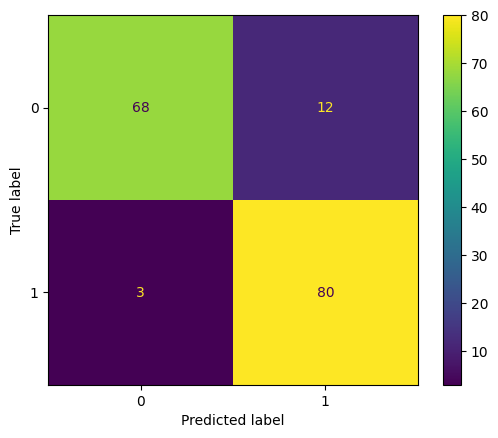

In [59]:
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(labels))
disp.plot()

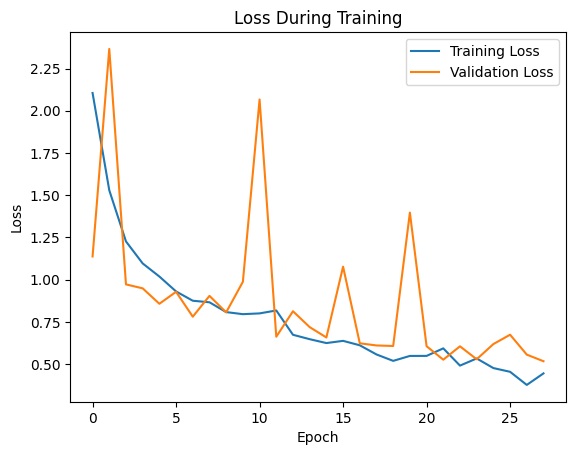

In [60]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss During Training')
plt.show()

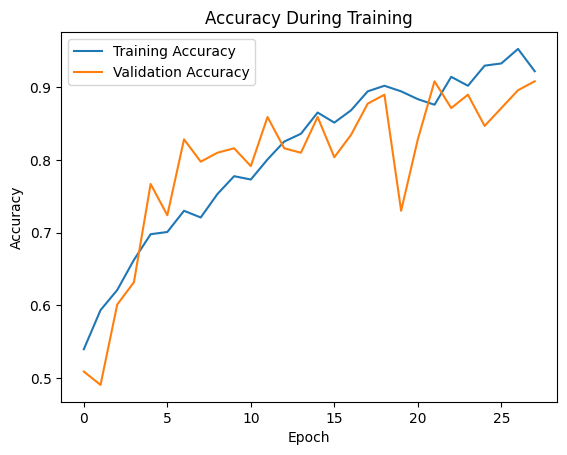

In [61]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy During Training')
plt.show()

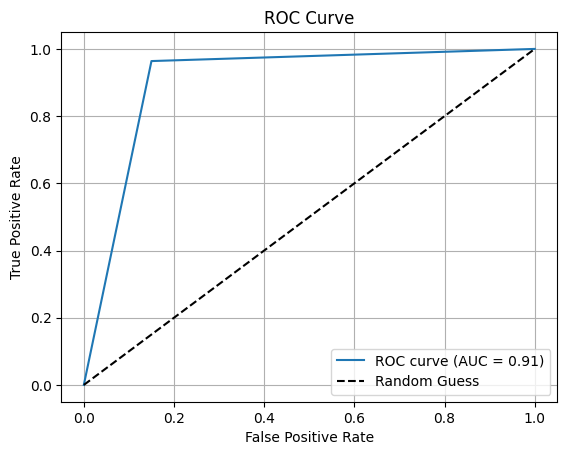

In [62]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [22]:
model.save('modelSuspicious.h5')
model.save('modelo.keras')